In [ ]:
import pandas as pd, numpy as np, torch, time, matplotlib.pyplot as plt

In [ ]:
import os, sys

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "../"))
BASE_DIR = os.path.join(ROOT_DIR, "predictor")

sys.path.append(ROOT_DIR)
sys.path.append(BASE_DIR)

for path in sys.path:
    if ROOT_DIR in path:
        print(path)
        
from predictor.methods import fetch_history, build_sequences, load_latest_model

/home/mt/root/Janus
/home/mt/root/Janus/predictor


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

def preprocess(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()[["Date", 'Rate']] 
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.set_index("Date").sort_index()
    data = data.resample("0.5h").mean().interpolate()
    return data

def scale(x, scaler=MinMaxScaler(), inverse: bool=False):
    if not inverse:
        return scaler.fit_transform(x)
    
    return scaler.inverse_transform(x)

def split(X, y, train_ratio: float, verbose: bool = False) -> tuple:
    TRAIN_SIZE = int(len(X) * train_ratio)
    X_train, y_train = X[:TRAIN_SIZE], y[:TRAIN_SIZE]
    X_test,  y_test  = X[TRAIN_SIZE:], y[TRAIN_SIZE:]
    
    if verbose:
        print(f"Train size: {X_train.shape[0]}\nTest size: {X_test.shape[0]}")
    return X_train, y_train, X_test, y_test

def evaluate_metrics(y_true, y_pred, verbose: bool = True) -> dict:
    """
    评估预测结果的常用回归指标。

    参数:
        y_true: 真实值 (1D array 或 Tensor)
        y_pred: 预测值 (1D array 或 Tensor)
        verbose: 是否打印指标

    返回:
        一个包含 MAE, MSE, RMSE, MAPE 的字典
    """
    # 若为 tensor，转为 numpy
    if hasattr(y_true, 'detach'):
        y_true = y_true.detach().cpu().numpy()
    if hasattr(y_pred, 'detach'):
        y_pred = y_pred.detach().cpu().numpy()

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # 避免除以 0
    nonzero_mask = y_true != 0
    if np.any(nonzero_mask):
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = np.nan

    if verbose:
        print(f"MAE  : {mae:.8f}")
        print(f"MSE  : {mse:.8f}")
        print(f"RMSE : {rmse:.8f}")
        print(f"MAPE : {mape * 100:.2f}%")

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "mape": mape
    }

In [4]:
def lstm_predict(currency: str, days: int=7):
    
    device = "cuda"
    model_dir = os.path.join(BASE_DIR, "models", "RateLSTM")
    model = load_latest_model(model_dir, currency, device, verbose=True)
    
    currency = currency.upper()
    df = preprocess(fetch_history(currency, 30))
    data = scale(df[['Rate']])

    seq = 48
    X, y = build_sequences(data, seq)
    X_train, _, X_test, y_test = split(X, y, 0.8)


    preds = scale(model.predict(X_test).cpu().numpy(), inverse=True)
    trues = scale(y_test.cpu().numpy(), inverse=True)
    dates = df.index[seq + len(X_train):]

    df_predict = pd.DataFrame({
        "Date": dates,
        "Currency": currency,
        "Rates": trues.flatten(),
        "Predicted_Rates": preds.flatten(),
        "local": time.strftime("%Y-%m-%d %H:%M:%S %Z", time.localtime())
    })
    
    # Generate future predictions
    future_steps = days * seq
    last_seq = data[-seq:].copy()
    future_scaled = []

    model.eval()
    for _ in range(future_steps):
        inp = torch.tensor(last_seq[np.newaxis, ...], dtype=torch.float32).to(device)
        with torch.no_grad():
            pred = model(inp).cpu().numpy().flatten()
        future_scaled.append(pred[0])
        last_seq = np.vstack([last_seq[1:], pred.reshape(1, 1)])

    future_scaled = np.array(future_scaled).reshape(-1, 1)
    future = scale(future_scaled, inverse=True)
    step = df.index[1] - df.index[0]
    future_dates = [df.index[-1] + (i+1)*step for i in range(future_steps)]

    df_forecast = pd.DataFrame({
        "Date": future_dates,
        "Currency": currency,
        "Predicted_Rates": future.flatten(),
        "local": time.strftime("%Y-%m-%d %H:%M:%S %Z", time.localtime())
    })

    evaluate_metrics(trues, preds)
    
    plt.figure(figsize=(14, 6))
    plt.plot(df_predict["Date"], df_predict["Rates"], label="Actual", linewidth=2)
    plt.plot(df_predict["Date"], df_predict["Predicted_Rates"], label="Predicted", linewidth=2)
    plt.plot(df_forecast["Date"], df_forecast["Predicted_Rates"], label="Forecast", linestyle="--")
    plt.xlabel("Date")
    plt.ylabel("Exchange Rate")
    plt.title(f"{currency.upper()} Exchange Rate Prediction + {days}-Days Forecast")
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return df_forecast

In [5]:
fetch_history('aud', 30)

,Date,Currency,Rate,Locals
0,2025-09-16 16:28:11,AUD,476.37,2025-09-16 18:00:04 ACST
1,2025-09-16 16:56:15,AUD,476.35,2025-09-16 18:30:04 ACST
2,2025-09-16 17:26:16,AUD,476.69,2025-09-16 19:00:04 ACST
3,2025-09-16 17:56:16,AUD,476.54,2025-09-16 19:30:02 ACST
4,2025-09-16 18:26:16,AUD,476.67,2025-09-16 20:00:04 ACST
...,...,...,...,...
724,2025-10-16 01:22:33,AUD,465.09,2025-10-16 04:00:04 ACDT
725,2025-10-16 01:56:44,AUD,465.44,2025-10-16 05:00:04 ACDT
726,2025-10-16 02:52:24,AUD,465.92,2025-10-16 08:00:02 ACDT
727,2025-10-16 05:30:00,AUD,465.92,2025-10-16 09:00:04 ACDT


🔍 Loading latest AUD model: /home/mt/root/Janus/predictor/models/RateLSTM/RateLSTM_AUD_202508.pth
MAE  : 0.46703213
MSE  : 0.35205337
RMSE : 0.59334086
MAPE : 10.05%


,Date,Currency,Predicted_Rates,local
0,2025-10-16 07:00:00,AUD,466.381653,2025-10-16 10:13:31 ACDT
1,2025-10-16 07:30:00,AUD,466.450745,2025-10-16 10:13:31 ACDT
2,2025-10-16 08:00:00,AUD,466.500702,2025-10-16 10:13:31 ACDT
3,2025-10-16 08:30:00,AUD,466.541229,2025-10-16 10:13:31 ACDT
4,2025-10-16 09:00:00,AUD,466.577942,2025-10-16 10:13:31 ACDT
...,...,...,...,...
331,2025-10-23 04:30:00,AUD,467.247589,2025-10-16 10:13:31 ACDT
332,2025-10-23 05:00:00,AUD,467.247589,2025-10-16 10:13:31 ACDT
333,2025-10-23 05:30:00,AUD,467.247589,2025-10-16 10:13:31 ACDT
334,2025-10-23 06:00:00,AUD,467.247589,2025-10-16 10:13:31 ACDT


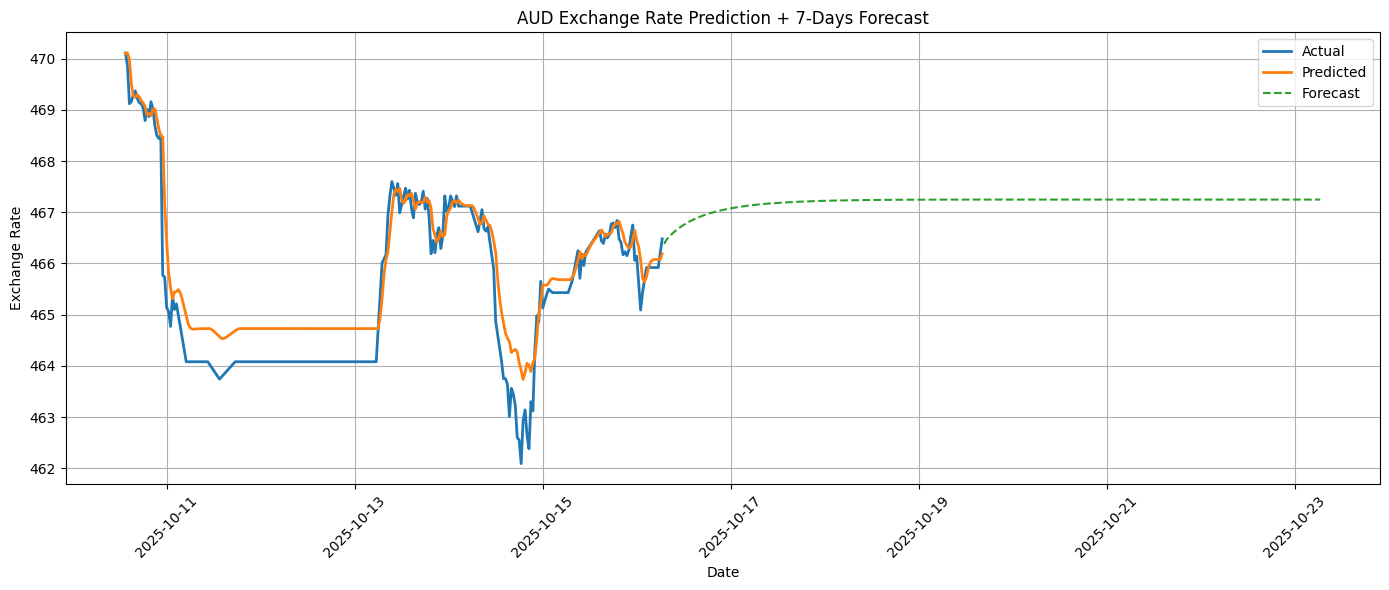

In [6]:
lstm_predict('aud')

🔍 Loading latest JPY model: /home/mt/root/Janus/predictor/models/RateLSTM/RateLSTM_JPY_202508.pth
MAE  : 0.00258395
MSE  : 0.00001408
RMSE : 0.00375167
MAPE : 5.47%


,Date,Currency,Predicted_Rates,local
0,2025-10-16 07:00:00,JPY,4.737631,2025-10-16 10:13:31 ACDT
1,2025-10-16 07:30:00,JPY,4.736667,2025-10-16 10:13:31 ACDT
2,2025-10-16 08:00:00,JPY,4.734755,2025-10-16 10:13:31 ACDT
3,2025-10-16 08:30:00,JPY,4.733000,2025-10-16 10:13:31 ACDT
4,2025-10-16 09:00:00,JPY,4.731457,2025-10-16 10:13:31 ACDT
...,...,...,...,...
331,2025-10-23 04:30:00,JPY,4.681323,2025-10-16 10:13:31 ACDT
332,2025-10-23 05:00:00,JPY,4.681323,2025-10-16 10:13:31 ACDT
333,2025-10-23 05:30:00,JPY,4.681323,2025-10-16 10:13:31 ACDT
334,2025-10-23 06:00:00,JPY,4.681323,2025-10-16 10:13:31 ACDT


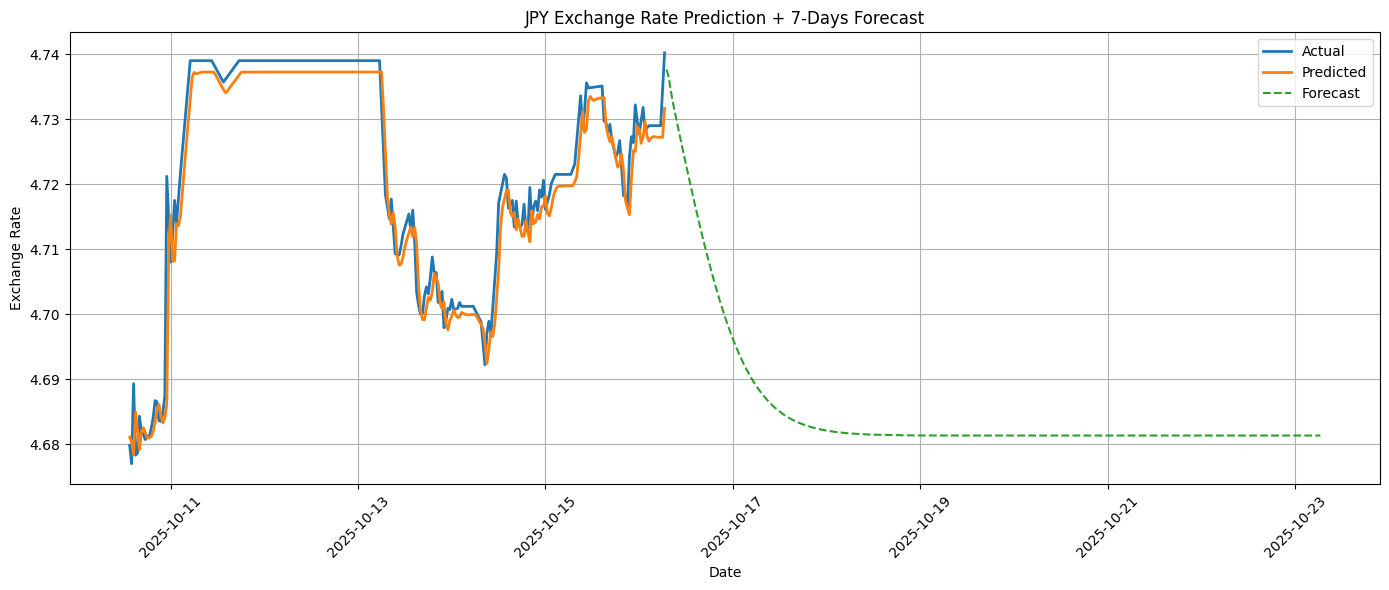

In [7]:
lstm_predict('jpy')

🔍 Loading latest USD model: /home/mt/root/Janus/predictor/models/RateLSTM/RateLSTM_USD_202508.pth
MAE  : 0.07115590
MSE  : 0.01470110
RMSE : 0.12124808
MAPE : 1.00%


,Date,Currency,Predicted_Rates,local
0,2025-10-16 07:00:00,USD,714.651001,2025-10-16 10:13:32 ACDT
1,2025-10-16 07:30:00,USD,714.667236,2025-10-16 10:13:32 ACDT
2,2025-10-16 08:00:00,USD,714.688782,2025-10-16 10:13:32 ACDT
3,2025-10-16 08:30:00,USD,714.715698,2025-10-16 10:13:32 ACDT
4,2025-10-16 09:00:00,USD,714.749268,2025-10-16 10:13:32 ACDT
...,...,...,...,...
331,2025-10-23 04:30:00,USD,715.731934,2025-10-16 10:13:32 ACDT
332,2025-10-23 05:00:00,USD,715.731934,2025-10-16 10:13:32 ACDT
333,2025-10-23 05:30:00,USD,715.731934,2025-10-16 10:13:32 ACDT
334,2025-10-23 06:00:00,USD,715.731934,2025-10-16 10:13:32 ACDT


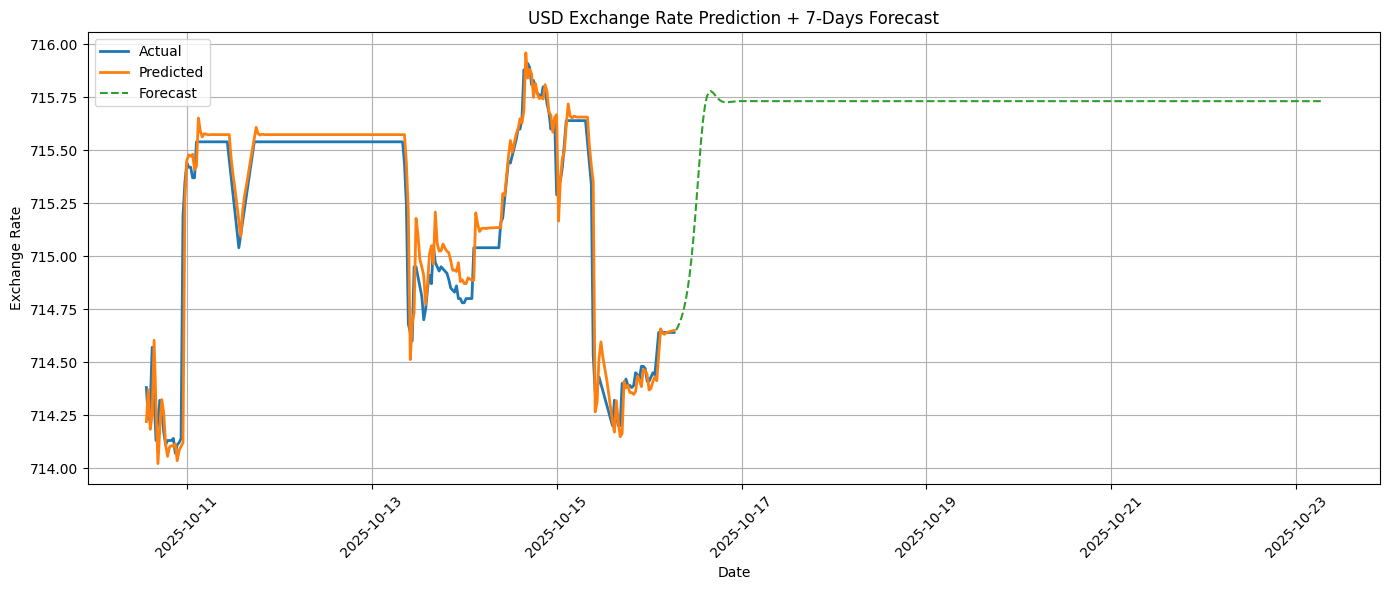

In [8]:
lstm_predict('usd')